In [ ]:
!pip install -r requirements.txt

## Average Travel Distance

1. Find straight line travel distance between OD pairs and generate a weighted average for each tract
2. Define the closest non-EPC tracts for each EPC neighbourhood as a comparison
3. Plot: weighted average of EPC vs neighbouring non-EPC commutes (do not use average of averages), individual plots of EPCs and their neighbours
4. Replace haversine distance with OSMnx routing distance

In [1]:
import pandas as pd

In [3]:
import sys
import os
from pathlib import Path

parent_path = Path.cwd().parent / "data/processed"

print("Data directory:", parent_path.resolve())

filename = "bay_area_lodes_od_table.parquet"
file_path = os.path.join(parent_path, filename)

bay_area_lodes = pd.read_parquet(file_path)

Data directory: /Users/licin/Documents/test urban info/data/processed


In [4]:
print(len(bay_area_lodes))
display(bay_area_lodes.head(10))
lodes_home_tracts = bay_area_lodes.groupby("home_tract")
display(lodes_home_tracts.head(10))

4083866


,index,w_geocode,h_geocode,S000,SA01,SA02,SA03,SE01,SE02,SE03,SI01,SI02,SI03,work_county,home_county,work_tract,home_tract,within_tract
0,0,060014001001003,060014001002002,1,0,0,1,0,0,1,0,0,1,06001,06001,06001400100,06001400100,True
1,1,060014001001003,060014001002018,1,0,0,1,0,0,1,0,0,1,06001,06001,06001400100,06001400100,True
2,2,060014001001003,060014008001013,1,0,1,0,0,0,1,0,0,1,06001,06001,06001400100,06001400800,False
3,3,060014001001003,060014010001004,1,0,1,0,0,0,1,0,0,1,06001,06001,06001400100,06001401000,False
4,4,060014001001003,060014016001025,1,0,0,1,0,0,1,0,0,1,06001,06001,06001400100,06001401600,False
5,5,060014001001003,060014035021002,1,0,1,0,0,0,1,0,0,1,06001,06001,06001400100,06001403502,False
6,6,060014001001003,060014040002006,1,0,0,1,0,0,1,0,0,1,06001,06001,06001400100,06001404000,False
7,7,060014001001003,060014045011006,1,0,1,0,0,0,1,0,0,1,06001,06001,06001400100,06001404501,False
8,8,060014001001003,060014069003003,1,0,1,0,0,0,1,0,0,1,06001,06001,06001400100,06001406900,False
9,9,060014001001003,060014206002013,1,0,0,1,0,0,1,0,0,1,06001,06001,06001400100,06001420600,False


,index,w_geocode,h_geocode,S000,SA01,SA02,SA03,SE01,SE02,SE03,SI01,SI02,SI03,work_county,home_county,work_tract,home_tract,within_tract
0,0,060014001001003,060014001002002,1,0,0,1,0,0,1,0,0,1,06001,06001,06001400100,06001400100,True
1,1,060014001001003,060014001002018,1,0,0,1,0,0,1,0,0,1,06001,06001,06001400100,06001400100,True
2,2,060014001001003,060014008001013,1,0,1,0,0,0,1,0,0,1,06001,06001,06001400100,06001400800,False
3,3,060014001001003,060014010001004,1,0,1,0,0,0,1,0,0,1,06001,06001,06001400100,06001401000,False
4,4,060014001001003,060014016001025,1,0,0,1,0,0,1,0,0,1,06001,06001,06001400100,06001401600,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15409702,15409702,060971534032010,060710114061016,1,1,0,0,0,0,1,1,0,0,06097,06071,06097153403,06071011406,False
15421583,15421583,060971538081003,060375411003006,1,0,0,1,0,0,1,0,0,1,06097,06037,06097153808,06037541100,False
15421836,15421836,060971538081005,060375356061006,1,0,0,1,0,1,0,0,0,1,06097,06037,06097153808,06037535606,False
15434878,15434878,060971541001031,060375404001000,1,0,0,1,0,1,0,1,0,0,06097,06037,06097154100,06037540400,False


### Routing - Haversine

1. Find centroid of tract
2. Find straight line distance between home tract and work tract

In [6]:
import sklearn
import shapely
import geopandas as gpd

parent_path = Path.cwd().parent / "data/processed"

print("Data directory:", parent_path.resolve())

filename = "bay_counties_cleaned.parquet"
file_path = os.path.join(parent_path, filename)

bay_counties = gpd.read_parquet(file_path)

Data directory: /Users/licin/Documents/test urban info/data/processed


In [7]:
bay_counties['centroid'] = bay_counties['geometry'].centroid
bay_counties.head()

/var/folders/zv/7h23jkj12tl1zd_4bsx6h9wr0000gn/T/ipykernel_91100/3895704142.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bay_counties['centroid'] = bay_counties['geometry'].centroid


,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,centroid
88,06,013,324002,06013324002,3240.02,Census Tract 3240.02,G5020,S,2027097,0,+37.9515743,-122.0605372,"POLYGON ((-122.07313 37.94793, -122.07276 37.9...",POINT (-122.06054 37.95157)
89,06,013,320004,06013320004,3200.04,Census Tract 3200.04,G5020,S,5911930,20167,+37.9992449,-122.0795275,"POLYGON ((-122.10187 38.00463, -122.10186 38.0...",POINT (-122.08062 38.00042)
90,06,013,336201,06013336201,3362.01,Census Tract 3362.01,G5020,S,1240588,0,+37.9604171,-122.0474661,"POLYGON ((-122.05429 37.95366, -122.05399 37.9...",POINT (-122.04747 37.96042)
91,06,013,338203,06013338203,3382.03,Census Tract 3382.03,G5020,S,1577045,0,+37.9256927,-122.0541352,"POLYGON ((-122.06394 37.91739, -122.06393 37.9...",POINT (-122.05413 37.92569)
92,06,013,338204,06013338204,3382.04,Census Tract 3382.04,G5020,S,2649159,15822,+37.9190883,-122.0467663,"POLYGON ((-122.05837 37.91039, -122.05836 37.9...",POINT (-122.04713 37.9189)


In [ ]:
# create df with cols home_tract, work_tract, home_centroid, work_centroid
# create new column, dist, to be haversine distance between home and work centroids

#dist = haversine_distances([])

### Routing - OSMnx

In [ ]:
# OSMnx documentation: https://github.com/gboeing/osmnx-examples

!uv pip install --system --quiet osmnx[all]

import numpy as np
import osmnx as ox

In [ ]:
bay_counties_place = ['Contra Costa, USA']#  Marin, Napa, San Francisco, San Mateo, Santa Clara, Solano, and Sonoma']
cf = '["highway"~"motorway|trunk|primary|secondary"]'#|motorway_link|trunk_link|primary_link|secondary_link"]'

G_bay = ox.graph.graph_from_place(bay_counties_place, custom_filter=cf)

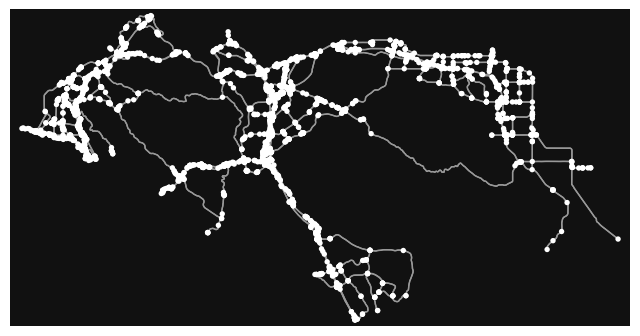

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
ox.plot_graph(G_bay)